# 11 · Multi-redshift SED explorer

Pick an output redshift, pick a galaxy, and see how well GALsPeCtrA reconstructs its
spectrum — the same question notebook 04 asks at z = 0, now across every snapshot the
model wrote.

## Two redshifts per snapshot

Each snapshot carries **two** redshifts and they are not interchangeable:

| | where it comes from | what it is for |
|---|---|---|
| `z_planck` | `input/zlists/zlist_planck_MR.txt`, the list the model evolved on | the epoch the galaxy is at — dust, distances, ages |
| `z_phot` | `input/zlists/zlist_wmap7_MR.txt` | the grid `ObsMag` was tabulated on |

The parameter file sets `PhotPrefix WMAP7` and only `WMAP7_*` photometric tables exist in
`SpecPhotTables/PhotTables/`, so L-GALAXIES' own observer-frame magnitudes are k-corrected
on the WMAP7 grid while the galaxies live on the Planck one. The gap runs from 0.12 at
z ≈ 0.3 to 0.26 at z ≈ 5 — large enough that redshifting a synthetic spectrum at
`z_planck` and comparing it to `ObsMag` produces tenth-of-a-magnitude colour residuals
that look like a broken k-correction.

So this notebook redshifts at **`z_phot`**, which makes the comparison against `ObsMag`
apples-to-apples, and prints `z_planck` beside it on every panel. The dust model uses
`z_planck`, because that is what `code/post_process_spec_mags.c:417` uses. `galspectra.lgalaxies.snapshots`
carries the full explanation.

> `z_phot` is clamped at zero. The z = 0 snapshot sits at WMAP7 z = −0.165, and a spectrum
> cannot be blueshifted.

## Merger tree

In [1]:
# ── Merger tree ─────────────────────────────────────────────────────────────
# Every per-tree constant comes from galspectra.trees so the sample file, the binary
# output and the coefficient product cannot disagree about which simulation this is.
# The redshift tag is *not* a per-tree constant — both trees use the same tags — so it
# is a separate argument to the path helpers rather than a second registry.
from galspectra.trees import get_tree

TREE = get_tree("MR")
print(f"Tree: {TREE.label}  ({TREE.pretty})")

Tree: MR  (Millennium-I)


## Setup — loaded once, shared by every redshift

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

PROJECT_ROOT = Path('..').resolve()
LGAL_ROOT    = PROJECT_ROOT.parent / 'L-GALAXIES' / 'LGalaxies2020_PublicRepository-master'
FILTER_DIR   = LGAL_ROOT / 'SpecPhotTables/Filters'

# ── Physical constants ────────────────────────────────────────────────────
_D_10PC_CM       = 3.0857e19
_FOUR_PI_10PC_SQ = 4.0 * np.pi * _D_10PC_CM**2
_YOUNG_THR_GYR   = 0.010   # 10 Myr birth-cloud boundary
_HUBBLE_H        = 0.673

# ── PCA basis ─────────────────────────────────────────────────────────────
pca            = np.load(PROJECT_ROOT / 'data/pca_results_bc03.npz', allow_pickle=True)
pca_wave       = pca['wave']
pca_components = pca['components']
pca_mean_pca   = pca['mean']
pca_params     = pca['params']
pca_param_names = list(pca['param_names'])
pca_cumvar     = np.cumsum(pca['variance'])
norm_meta      = pca['norm'].item() if pca['norm'].ndim == 0 else dict(pca['norm'])

# ── galspectra modules ────────────────────────────────────────────────────
from galspectra.lgalaxies import (load_sample, load_sfh_table, extract_sfh,
                                  discover_tags, snapshots)
from galspectra.utils.grid import build_param_grid
from galspectra.csp.interpolator import PCACoefficientInterpolator
from galspectra.csp.builder import build_csp_coefficients
from galspectra.csp.reconstruct import reconstruction_sed_from_pca
from galspectra.photometry.filters import load_sdss_filters
from galspectra.photometry.synthetic import compute_ab_magnitudes
from galspectra.photometry.redshift import observed_frame
from galspectra.photometry.dust import apply_dust_to_seds
from galspectra.cosmology import cosmology

COSMO = cosmology()          # FlatLambdaCDM, H0 = 67.3, Om0 = 0.315

sfh_table = load_sfh_table(LGAL_ROOT / 'AuxCode/Python/Database_SFH_table.fits')
ages_grid, Z_grid, coeff_grid = build_param_grid(pca_params, pca['coeffs'], pca_param_names)
interpolator = PCACoefficientInterpolator(ages_grid, Z_grid, coeff_grid)
filters  = load_sdss_filters(FILTER_DIR)
bands    = ['u', 'g', 'r', 'i', 'z']
band_idx = {b: i for i, b in enumerate(bands)}

# ── BC03 library for the direct (non-PCA) reference SED ───────────────────
from galspectra.sps.bc03_backend import BC03Library, get_bc03_spectrum, BC03_METALLICITIES
BC03_DIR  = LGAL_ROOT / 'SpecPhotTables/FullSEDs'
_bc03_lib = BC03Library(BC03_DIR,
                        wave_min=float(pca_wave[0]), wave_max=float(pca_wave[-1]))
print('Pre-loading BC03 files...', end=' ', flush=True)
for _Z in BC03_METALLICITIES:
    _bc03_lib.get(_Z)
print('done.')

print(f'PCA basis : {pca_components.shape[0]} components over {len(pca_wave)} bins '
      f'({pca_wave[0]:.0f}-{pca_wave[-1]:.0f} A)')

(1200, 2)
[[ 1.00000000e-04 -2.30103000e+00]
 [ 1.00000000e-04 -1.69897000e+00]
 [ 1.00000000e-04 -6.98970004e-01]
 [ 1.00000000e-04 -3.97940009e-01]
 [ 1.00000000e-04  0.00000000e+00]
 [ 1.00000000e-04  3.97940009e-01]
 [ 1.06123769e-04 -2.30103000e+00]
 [ 1.06123769e-04 -1.69897000e+00]
 [ 1.06123769e-04 -6.98970004e-01]
 [ 1.06123769e-04 -3.97940009e-01]]
Pre-loading BC03 files... done.
PCA basis : 50 components over 831 bins (805-29950 A)


## Which redshifts are available

Read off the disk rather than from a list written here, so this notebook stays correct
after a run with a different `desired_output_redshifts.txt`. A tag with a sample but no
coefficient product is reported and then skipped — the fix is to run
`scripts/run_multiz_coeffs.sh`, not to edit this cell.

In [3]:
TAGS_ON_DISK = discover_tags(TREE, LGAL_ROOT)
SNAPS = {s.tag: s for s in snapshots(LGAL_ROOT, tags=TAGS_ON_DISK)}

# A tag is usable only if the coefficient product exists too. Both are needed for
# every panel below, so filtering here means no widget selection can half-work.
# The z = 0 product keeps the unsuffixed name it had before the multi-redshift run;
# the registry normalises a '0.00' tag onto it, so there is no special case here.
def _coeffs_file(tag):
    return TREE.coeffs_path(PROJECT_ROOT / 'data', tag)

USABLE = [t for t in TAGS_ON_DISK if _coeffs_file(t).exists()]
MISSING = [t for t in TAGS_ON_DISK if t not in USABLE]

print(f'{"tag":>6}{"snap":>6}{"z_planck":>11}{"z_phot":>9}{"delta":>8}   coefficients')
print('-' * 62)
for tag in TAGS_ON_DISK:
    s = SNAPS[tag]
    ok = 'yes' if tag in USABLE else f'MISSING -> {_coeffs_file(tag).name}'
    print(f'{tag:>6}{s.snap:>6}{s.z_planck:>11.4f}{s.z_phot:>9.4f}'
          f'{s.z_phot - s.z_planck:>8.4f}   {ok}')

if MISSING:
    print(f'\n{len(MISSING)} redshift(s) have a sample but no coefficients; '
          f'run scripts/run_multiz_coeffs.sh to build them.')
assert USABLE, 'no redshift has both a sample and a coefficient product'

# ── One x-axis for every SFH panel ────────────────────────────────────────
# Derived from the bin table over the snapshots actually on disk, not hard-coded, so
# a run with a different desired_output_redshifts.txt still gets limits that hold
# every bar. Fixing this is the whole point: autoscaling stretched a 1.1 Gyr history
# at z = 5 to the same width as a 13.8 Gyr one at z = 0, which is precisely the
# difference between the two that you want to see.
from galspectra.lgalaxies import get_snap_sfh_times
_edges = [get_snap_sfh_times(sfh_table, SNAPS[t].snap) for t in USABLE]
SFH_XLIM = (min(dt.min() for _, dt in _edges) / 2.0,
            max((lt + dt / 2).max() for lt, dt in _edges) * 1.1)
print(f'\nSFH x-axis, fixed for every panel: '
      f'{SFH_XLIM[0] * 1e3:.1f} Myr to {SFH_XLIM[1]:.1f} Gyr lookback')

   tag  snap   z_planck   z_phot   delta   coefficients
--------------------------------------------------------------
  0.00    58     0.0003   0.0000 -0.0003   yes
  0.26    50     0.2626   0.1249 -0.1377   yes
  0.51    45     0.5133   0.3873 -0.1260   yes
  0.78    41     0.7840   0.6621 -0.1219   yes
  1.04    38     1.0415   0.9188 -0.1227   yes
  1.48    34     1.4817   1.3510 -0.1307   yes
  2.07    30     2.0700   1.9223 -0.1477   yes
  2.44    28     2.4371   2.2769 -0.1602   yes
  3.11    25     3.1053   2.9202 -0.1851   yes
  5.03    19     5.0324   4.7695 -0.2629   yes

SFH x-axis, fixed for every panel: 2.8 Myr to 15.2 Gyr lookback


## Per-redshift data, loaded on demand

Ten samples is roughly 750 MB, so they are cached as they are asked for rather than all
at once. The cache holds the sample array, the coefficient product and the derived
selection quantities together, because a galaxy index is only meaningful against the
sample it came from — keeping them in separate globals is how an index from one redshift
comes to be used against another.

In [4]:
from dataclasses import dataclass

@dataclass
class RedshiftData:
    """Everything needed to work with one output redshift."""
    tag: str
    snap: object          # galspectra.lgalaxies.Snapshot
    G: np.ndarray         # the sample
    coeffs: np.ndarray    # (N, 50) stored CSP coefficients

    @property
    def mag(self):     return self.G['Mag']
    @property
    def magdust(self): return self.G['MagDust']
    @property
    def obsmag(self):     return self.G['ObsMag']
    @property
    def obsmagdust(self): return self.G['ObsMagDust']


_CACHE = {}

def load_redshift(tag):
    """The RedshiftData for one tag, loading and caching on first use."""
    if tag in _CACHE:
        return _CACHE[tag]

    G = load_sample(TREE.require(TREE.sample_path(LGAL_ROOT, tag), 'a galaxy sample'))
    synth = np.load(TREE.require(_coeffs_file(tag), 'a PCA coefficient product'))
    coeffs = synth['pca_coeffs']

    # The coefficient product is written by iterating the sample in order, so row i of
    # one is galaxy i of the other. If the sample has been rebuilt since, that identity
    # is silently broken and every SED below would belong to a different galaxy.
    if len(coeffs) != len(G):
        raise ValueError(
            f"z{tag}: coefficient product has {len(coeffs):,} rows but the sample has "
            f"{len(G):,} galaxies. One of them is stale — rebuild the coefficients with "
            f"scripts/process_lgalaxies.py."
        )

    snaps_in_sample = np.unique(G['SnapNum'])
    assert len(snaps_in_sample) == 1 and snaps_in_sample[0] == SNAPS[tag].snap, (
        f"z{tag}: sample holds snapshot(s) {list(snaps_in_sample)}, expected "
        f"{SNAPS[tag].snap}")

    _CACHE[tag] = RedshiftData(tag=tag, snap=SNAPS[tag], G=G, coeffs=coeffs)
    return _CACHE[tag]


def selection_quantities(d):
    """B/T, log M*, g-r, sSFR and a validity mask for the galaxy picker."""
    G = d.G
    mstar = G['StellarMass'] + 1e-10
    return dict(
        bt       = G['BulgeMass'] / mstar,
        logmstar = np.log10(mstar),
        gr       = d.mag[:, band_idx['g']] - d.mag[:, band_idx['r']],
        sfr      = G['Sfr'],
        ssfr     = G['Sfr'] / mstar,
        valid    = (d.mag[:, band_idx['r']] < 90.0) & (d.magdust[:, band_idx['r']] < 90.0),
    )

## Reconstruction

Identical to notebook 04's path — the stored coefficient vector for the intrinsic SED,
the four young/old × disk/bulge sub-SEDs rebuilt for the dust model — with one change:
the dust column density is evaluated at `z_planck` instead of at zero, matching
`code/post_process_spec_mags.c:417`'s `n_H ∝ (1+z)⁻¹`. At z = 5 that is a factor of six in column
density, so it is not a refinement.

In [5]:
FILTER_COLORS = {'u': '#7B2FBE', 'g': '#4CAF50', 'r': '#F44336',
                 'i': '#FF9800', 'z': '#795548'}

def _reconstruct_abs(coeffs_n, mass, components_n):
    """Reconstruct an SED from PCA coefficients, scaled to flux at 10 pc."""
    if mass <= 0:
        return np.zeros(len(pca_wave))
    sed_per_msun = reconstruction_sed_from_pca(
        coeffs_n / mass, components_n, pca_mean_pca, norm_meta)
    return sed_per_msun * mass / _FOUR_PI_10PC_SQ


def reconstruct_sed(d, gidx, n_components=50, rng=None):
    """Intrinsic and dust-attenuated rest-frame SEDs for one galaxy. Returns (i, d, sfh)."""
    if rng is None:
        rng = np.random.default_rng(gidx)      # fixed seed -> reproducible dust draw

    sfh  = extract_sfh(d.G[gidx], sfh_table)
    ages = sfh['age_Gyr']
    P_n  = pca_components[:n_components]

    total_mass = sfh['disk_mass'].sum() + sfh['bulge_mass'].sum()
    sed_i = _reconstruct_abs(d.coeffs[gidx][:n_components], total_mass, P_n)

    is_young = ages < _YOUNG_THR_GYR
    is_old   = ~is_young

    def _sub(mask, Z_key, mass_key):
        m = sfh[mass_key][mask].sum()
        if m <= 0:
            return np.zeros(len(pca_wave))
        c = build_csp_coefficients(interpolator, ages[mask],
                                   sfh[Z_key][mask], sfh[mass_key][mask])
        return _reconstruct_abs(c[:n_components], m, P_n)

    sed_d = apply_dust_to_seds(
        pca_wave,
        _sub(is_old,   'logzsol_disk',  'disk_mass'),
        _sub(is_young, 'logzsol_disk',  'disk_mass'),
        _sub(is_old,   'logzsol_bulge', 'bulge_mass'),
        _sub(is_young, 'logzsol_bulge', 'bulge_mass'),
        float(d.G[gidx]['ColdGas']),
        float(d.G[gidx]['ColdGasRadius']),
        d.G[gidx]['MetalsColdGas'],
        float(d.G[gidx]['CosInclination']),
        redshift=d.snap.z_planck,      # the epoch the galaxy is at
        hubble_h=_HUBBLE_H, rng=rng,
    )
    return sed_i, sed_d, sfh


def reconstruct_sed_direct(d, gidx):
    """The same CSP summed straight from BC03 spectra, with no PCA in the path.

    This is the reference the PCA curve is judged against: the difference between the
    two is compression error and nothing else, because both use the same SFH, the same
    metallicities and the same dust draw.
    """
    sfh  = extract_sfh(d.G[gidx], sfh_table)
    ages = sfh['age_Gyr']
    parts = {k: np.zeros(len(pca_wave))
             for k in ('disk_old', 'disk_young', 'bulge_old', 'bulge_young')}

    for j, age in enumerate(ages):
        tag = 'young' if age < _YOUNG_THR_GYR else 'old'
        for comp, mass_key, z_key in (('disk',  'disk_mass',  'Z_disk'),
                                      ('bulge', 'bulge_mass', 'Z_bulge')):
            m = sfh[mass_key][j]
            if m > 0:
                # (wave, flux); the library was trimmed to the PCA grid at load time,
                # so flux is already on pca_wave and needs no resampling.
                _, flux = get_bc03_spectrum(age, sfh[z_key][j], BC03_DIR, _bc03_lib)
                parts[f'{comp}_{tag}'] += flux * m / _FOUR_PI_10PC_SQ

    sed_i = sum(parts.values())
    sed_d = apply_dust_to_seds(
        pca_wave, parts['disk_old'], parts['disk_young'],
        parts['bulge_old'], parts['bulge_young'],
        float(d.G[gidx]['ColdGas']), float(d.G[gidx]['ColdGasRadius']),
        d.G[gidx]['MetalsColdGas'], float(d.G[gidx]['CosInclination']),
        redshift=d.snap.z_planck, hubble_h=_HUBBLE_H,
        rng=np.random.default_rng(gidx),   # same seed as reconstruct_sed
    )
    return sed_i, sed_d

## Galaxy picker

In [6]:
def archetypes(d):
    """Four galaxies spanning the population at this redshift, as {label: index}.

    The z = 0 cuts of notebook 04 do not transplant: at z > 2 essentially nothing is
    both massive and quenched, and a fixed g-r threshold selects a different rest-frame
    colour once the population as a whole is bluer. So the cuts here are *relative* —
    percentiles of this redshift's own distribution — and each returns None rather than
    a nearest-miss when the population genuinely has no such galaxy.
    """
    q = selection_quantities(d)
    ok = q['valid'] & (q['logmstar'] > np.percentile(q['logmstar'][q['valid']], 50))
    if ok.sum() < 8:
        ok = q['valid']

    gr_lo, gr_hi = np.percentile(q['gr'][ok], [25, 75])
    out = {}

    def _pick(label, mask, sort_by, take_max):
        idx = np.where(mask & ok)[0]
        if len(idx) == 0:
            out[label] = None
            return
        order = idx[np.argsort(sort_by[idx])]
        out[label] = int(order[-1] if take_max else order[len(order) // 2])

    _pick('Reddest, bulge-dominated', (q['bt'] > 0.6) & (q['gr'] > gr_hi), q['gr'],   True)
    _pick('Bluest disc',              (q['bt'] < 0.3) & (q['gr'] < gr_lo), q['gr'],   False)
    _pick('Intermediate colour',      (q['gr'] > gr_lo) & (q['gr'] < gr_hi), q['gr'], False)
    _pick('Highest sSFR',             np.ones(len(q['bt']), bool),          q['ssfr'], True)
    return out


def describe(d, gidx):
    """One line of galaxy properties, for the panel headings."""
    q = selection_quantities(d)
    return (f"logM* = {q['logmstar'][gidx]:.2f}   g-r = {q['gr'][gidx]:.3f}   "
            f"B/T = {q['bt'][gidx]:.2f}   SFR = {q['sfr'][gidx]:.3f} Msun/yr")

## The explorer

Four panels per selection:

1. **SFH** — mass per bin against lookback time, drawn as bars of the true bin *width*,
   disk and bulge overlaid at 55 % opacity so neither hides the other.

   **"Lookback time from the snapshot" means time measured backwards from that
   snapshot's own epoch, not from z = 0.** `write_sfh_bins()` (`code/save.c:903`) stores
   `SFH_t + dt/2 - NumToTime(snap)`: the bin's time-to-z=0 minus the *snapshot's*
   time-to-z=0. So bin 0 is the snapshot itself, and the oldest bin reaches back to
   snapshot 0 at z = 56.4 — which makes the total span the age of the universe at that
   snapshot: 13.78 Gyr at z = 0, 5.65 at z = 1.04, **1.12 at z = 5.03**.

   The x-axis is therefore **fixed across every redshift**, so that shrinking span is
   visible instead of being scaled away. The top axis converts the same positions into
   the redshift the stars formed at, and re-maps as you change snapshot.

   The adaptive binning is visible here too: `create_sfh_bins()` opens one bin per
   sub-timestep and merges them in powers of two, so bins are ~18 Myr wide at the output
   time and grow to gigayears at the oldest ages. How many are populated
   (`sfh_ibin + 1`) changes from snapshot to snapshot — it is not a fixed 20.
2. **Rest-frame SED** — PCA against the direct BC03 sum, intrinsic and dust-attenuated,
   with SDSS transmission curves overlaid at their *rest* positions.
3. **Observer-frame SED** — the same spectrum at `z_phot`, with the filters at their
   fixed observed positions, so you can see which rest-frame wavelengths each band is
   actually sampling.
4. **Photometry** — synthetic ugriz against L-GALAXIES' own `Mag`/`MagDust` (rest) and
   `ObsMag`/`ObsMagDust` (observer frame).

A band the observed grid does not span is dropped rather than extrapolated, and it is the
**blue** bands that go. Redshifting moves the basis red: the 805–29950 Å rest-frame grid
becomes 4645–172800 Å observed at z = 4.77, so *u* (3000–4000 Å) has nothing underneath it
at all and *g* is cut through its blue wing. Integrating a filter that runs off the grid
returns the flux of the covered part only — a magnitude too faint by an amount that looks
like astrophysics — so `_covered()` requires 99 % of each transmission curve's integral to
lie inside the grid before a band is reported.

> **Read the dust-free rows for agreement.** The dust rows disagree for two reasons, and
> the larger one is not on this side.
>
> 1. **`MagDust` in this run is very nearly `Mag`.** Measured over the 10,147 valid z = 0
>    galaxies, the median attenuation L-GALAXIES applies is **0.000 mag in every band**,
>    the mean is 0.025, and only 2–3 % of galaxies are attenuated by more than 0.01 mag.
>    The cause is `Zg /= o->ColdGas/0.02` in `post_process_spec_mags.c:64` (and the same
>    expression in `model_dust.c:96`). That evaluates to `0.02 x (M_metals/M_cold)`,
>    whereas the Mathis scaling `A_lam/A_V ∝ (Z_gas/Z_sun)^1.6` wants
>    `(M_metals/M_cold)/0.02` — a factor of 2500 low, which `^1.6` turns into ~1e-9 in the
>    optical depth. For a typical disc that is A_r = 0.0000 mag where the model intends
>    ~0.26. GALsPeCtrA uses the intended convention (`photometry/dust.py:231`), so its
>    dust rows are the *more* physical ones here. Both files are unmodified upstream
>    L-GALAXIES 2020 — this is not something the multi-redshift run introduced.
> 2. **The birth-cloud factor mu is a random draw.** `draw_mu()` samples a clamped
>    Gaussian(0.3, 0.2) and L-GALAXIES draws its own independently, so even with the
>    metallicity fixed only the *distributions* would be comparable, never a single
>    galaxy. Notebook 05 is where that comparison belongs.

In [7]:
MAG_SENTINEL = 90.0

def _covered(wave_obs, band, min_coverage=0.99):
    """Whether the basis spans enough of a filter to photometer it honestly.

    Integrating a filter that runs off the end of the grid silently returns the flux of
    the part that is covered, which is a magnitude that is too faint by an amount
    nobody can see. Coverage is measured on the transmission curve's own integral, so a
    band cut in its wing is treated more leniently than one cut through its peak.
    """
    wf, tf = filters[band]
    total = np.trapezoid(tf, wf)
    inside = (wf >= wave_obs[0]) & (wf <= wave_obs[-1])
    return total > 0 and np.trapezoid(tf * inside, wf) / total >= min_coverage


def _mags(wave, sed, only=None):
    """AB magnitudes on the bands that `wave` actually covers."""
    names = only if only is not None else [b for b in bands if _covered(wave, b)]
    if not names:
        return {}
    return compute_ab_magnitudes(wave, sed, {b: filters[b] for b in names})


def _filter_overlay(ax, wave, scale=1.0):
    for band, (wf, tf) in filters.items():
        t = np.interp(wave, wf, tf, left=0.0, right=0.0)
        if not np.any(t > 0):
            continue
        ax.fill_between(wave, t * scale, alpha=0.10, color=FILTER_COLORS[band], lw=0)
        peak = int(np.argmax(t))
        ax.text(wave[peak], t[peak] * scale * 1.08, band, ha='center', va='bottom',
                fontsize=8, color=FILTER_COLORS[band], fontweight='bold')


#: Candidate formation redshifts for the SFH panel's top axis. Round numbers, spanning
#: everything reachable from any snapshot; which ones are actually drawn is decided per
#: snapshot in `_redshift_top_axis`.
_Z_TICKS = [0.05, 0.1, 0.2, 0.3, 0.5, 0.7, 1, 1.5, 2, 3, 4, 5, 6, 7, 8, 10, 15, 20, 30, 50]


def _redshift_top_axis(ax, z_snap, xlim):
    """Add a top x-axis ticked in the redshift the stars formed at.

    The bottom axis is lookback time *from the snapshot*, which is fixed for every
    panel; this one re-maps with the snapshot, so the same physical position means a
    different formation redshift at z = 0 than at z = 5. That contrast is what makes
    the fixed bottom axis readable.

        t_lookback  ->  T_form = age(z_snap) - t_lookback  ->  z_form

    Ticks are found by evaluating `age(z_f)` forwards for each candidate and keeping
    the ones that land in range — never by inverting age -> z with `z_at_value`, which
    is a root-find, is slow inside an interactive callback, and misbehaves at the ends.

    Returns the (z, lookback) pairs drawn, so a test can check them.
    """
    age_snap = float(COSMO.age(z_snap).value)          # Gyr
    log_span = np.log10(xlim[1]) - np.log10(xlim[0])

    drawn, last_log = [], -np.inf
    for z_f in _Z_TICKS:
        if z_f <= z_snap:
            continue                                   # stars cannot form after the snapshot
        t_lb = age_snap - float(COSMO.age(z_f).value)
        if not (xlim[0] <= t_lb <= xlim[1]):
            continue
        # Thin to keep the labels apart: at z = 0 all twenty candidates are in range and
        # the low-z ones pile into the same few pixels.
        if np.log10(t_lb) - last_log < 0.04 * log_span:
            continue
        drawn.append((z_f, t_lb))
        last_log = np.log10(t_lb)

    top = ax.twiny()
    top.set_xscale('log')
    top.set_xlim(*xlim)
    top.set_xticks([t for _, t in drawn])
    top.set_xticklabels([f'{z:g}' for z, _ in drawn], fontsize=8)
    top.set_xlabel('redshift the stars formed at', fontsize=9)
    top.tick_params(axis='x', which='minor', top=False)
    top.grid(False)
    return drawn


def _sfh_panel(ax, sfh, snap):
    """Mass per SFH bin against lookback time, drawn at the true bin widths.

    Three deliberate choices.

    **Bars are placed by their edges**, not centre-and-width. The youngest bin reaches
    the snapshot itself, so its left edge is zero, and a log axis asked to start there
    quietly rescales to 1e-15 and squashes every bar against the right-hand side.

    **Disk and bulge overlap rather than stack.** Stacked, a bulge three orders of
    magnitude below the disk is a hairline; and on a log axis stacked heights do not
    read additively anyway, so the stack was not buying the accuracy it appeared to.
    Both series are drawn from zero at alpha 0.55, so the overlap reads as a blend and
    neither can hide behind the other.

    **The x-axis is the same on every panel** (`SFH_XLIM`). The bars stopping earlier
    at high redshift *is* the result: lookback time here is measured from the snapshot,
    so the span is the age of the universe at that epoch — 13.8 Gyr at z = 0, 1.1 Gyr
    at z = 5.
    """
    lt, dt = sfh['age_Gyr'], sfh['dt_Gyr']
    left = np.maximum(lt - dt / 2.0, 0.0)
    disk, bulge = sfh['disk_mass'], sfh['bulge_mass']

    ax.bar(left, disk, width=dt, align='edge', color='#2E7DD6', alpha=0.55,
           edgecolor='#12508F', lw=0.7, label='disk', zorder=2)
    ax.bar(left, bulge, width=dt, align='edge', color='#D65C2E', alpha=0.55,
           edgecolor='#8F3312', lw=0.7, label='bulge', zorder=3)

    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlim(*SFH_XLIM)

    # y-limits from the larger of the two series, not their sum -- they no longer stack,
    # and using the sum would leave a small bulge sitting below the axis.
    #
    # The floor is clamped to five decades below the peak. Overlaying rather than
    # stacking exposed bins holding numerically negligible mass -- a pure-bulge galaxy
    # with a 1e-5 Msun disk bin is real but meaningless, and letting it set the limit
    # stretched the panel over sixteen decades and flattened the actual history.
    both = np.concatenate([disk, bulge])
    if np.any(both > 0):
        peak = both.max()
        ax.set_ylim(max(both[both > 0].min() * 0.4, peak * 1e-5), peak * 3.0)

    ax.set_xlabel('Lookback time from the snapshot (Gyr)')
    ax.set_ylabel('Mass formed per bin (Msun)')
    ax.legend(fontsize=8, frameon=False, loc='upper left')
    ax.grid(alpha=0.2, which='both', lw=0.4)

    _redshift_top_axis(ax, snap.z_planck, SFH_XLIM)
    # pad clears the twin axis's ticks *and* its label, which matplotlib stacks above
    # the panel; without it the title lands on top of them.
    ax.set_title(f"SFH at z = {snap.z_planck:.4f} -- {sfh['n_bins']} populated bins, "
                 f"{dt.min() * 1e3:.0f} Myr to {dt.max():.2f} Gyr wide",
                 fontsize=10, pad=42)


def _sed_panel(ax, wave, curves, title, xlabel):
    for y, color, ls, lw, label, alpha in curves:
        ax.plot(wave, y, color=color, ls=ls, lw=lw, label=label, alpha=alpha)
    _filter_overlay(ax, wave)
    ax.set_yscale('log'); ax.set_xscale('log')
    positive = np.concatenate([c[0][c[0] > 0] for c in curves if np.any(c[0] > 0)])
    if len(positive):
        ax.set_ylim(np.percentile(positive, 1) * 0.3, positive.max() * 3)
    ax.set_xlim(wave[0], wave[-1])
    ax.set_xlabel(xlabel); ax.set_ylabel('Flux (erg/s/A/cm2)')
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=8, frameon=False, loc='lower right')
    ax.grid(alpha=0.2, which='both', lw=0.4)


def _phot_panel(ax, rows):
    """A text table of synthetic vs native magnitudes. rows: (heading, dict) pairs."""
    ax.axis('off')
    lines = [f"{'':22}{'u':>8}{'g':>8}{'r':>8}{'i':>8}{'z':>8}"]
    for heading, values in rows:
        cells = ''.join(
            f'{values[b]:>8.3f}' if (b in values and np.isfinite(values[b])
                                     and abs(values[b]) < MAG_SENTINEL) else f'{"--":>8}'
            for b in bands)
        lines.append(f'{heading:22}{cells}')
    ax.text(0.0, 1.0, '\n'.join(lines), family='monospace', fontsize=9.5,
            va='top', ha='left', transform=ax.transAxes)


def show(tag, gidx, n_components=50):
    """Draw the four panels for one galaxy at one redshift."""
    d   = load_redshift(tag)
    s   = d.snap
    sed_i, sed_d, sfh = reconstruct_sed(d, gidx, n_components)
    sed_i_dir, sed_d_dir = reconstruct_sed_direct(d, gidx)
    wave_obs, sed_i_obs = observed_frame(pca_wave, sed_i, s.z_phot)
    _,        sed_d_obs = observed_frame(pca_wave, sed_d, s.z_phot)

    fig, axes = plt.subplots(2, 2, figsize=(15, 9))
    fig.suptitle(
        f'snapshot {s.snap}  ·  z_planck = {s.z_planck:.4f}  ·  '
        f'z_phot = {s.z_phot:.4f}  ·  galaxy #{gidx}\n{describe(d, gidx)}',
        fontsize=11)

    _sfh_panel(axes[0, 0], sfh, s)

    _sed_panel(axes[0, 1], pca_wave, [
        (sed_i,     'black',   '-',  2.0, 'PCA intrinsic',    1.0),
        (sed_d,     'crimson', '-',  2.0, 'PCA dust-att.',    0.6),
        (sed_i_dir, 'gray',    '--', 1.4, 'Direct intrinsic', 0.8),
        (sed_d_dir, 'darkred', '--', 1.4, 'Direct dust-att.', 0.8),
    ], f'Rest frame — {n_components} PCA components '
       f'({pca_cumvar[n_components - 1] * 100:.3f}% variance)',
       'Rest wavelength (A)')

    _sed_panel(axes[1, 0], wave_obs, [
        (sed_i_obs, 'black',   '-', 2.0, 'PCA intrinsic', 1.0),
        (sed_d_obs, 'crimson', '-', 2.0, 'PCA dust-att.', 0.6),
    ], f'Observer frame at z = {s.z_phot:.4f}', 'Observed wavelength (A)')

    native_rest = {b: d.mag[gidx, band_idx[b]] for b in bands}
    native_rest_d = {b: d.magdust[gidx, band_idx[b]] for b in bands}
    native_obs = {b: d.obsmag[gidx, band_idx[b]] for b in bands}
    native_obs_d = {b: d.obsmagdust[gidx, band_idx[b]] for b in bands}
    mine_rest   = _mags(pca_wave, sed_i)
    mine_rest_d = _mags(pca_wave, sed_d)
    mine_obs    = _mags(wave_obs, sed_i_obs)
    mine_obs_d  = _mags(wave_obs, sed_d_obs)

    def _delta(mine, native):
        return {b: mine[b] - native[b] for b in mine
                if np.isfinite(native[b]) and abs(native[b]) < MAG_SENTINEL}

    _phot_panel(axes[1, 1], [
        ('rest  GALsPeCtrA',   mine_rest),
        ('rest  L-GALAXIES',   native_rest),
        ('rest  difference',   _delta(mine_rest, native_rest)),
        ('rest+dust  ours',    mine_rest_d),
        ('rest+dust  theirs',  native_rest_d),
        ('rest+dust  diff',    _delta(mine_rest_d, native_rest_d)),
        ('obs  GALsPeCtrA',    mine_obs),
        ('obs  L-GALAXIES',    native_obs),
        ('obs  difference',    _delta(mine_obs, native_obs)),
        ('obs+dust  ours',     mine_obs_d),
        ('obs+dust  theirs',   native_obs_d),
        ('obs+dust  diff',     _delta(mine_obs_d, native_obs_d)),
    ])
    axes[1, 1].set_title('Absolute AB magnitudes (10 pc); "--" = band off the basis\n'
                         'compare the dust-FREE rows -- see the note above on MagDust',
                         fontsize=10)

    fig.tight_layout(rect=[0, 0, 1, 0.94])
    plt.show()

### Interactive

In [8]:
from ipywidgets import interactive_output, Dropdown, IntSlider, BoundedIntText, VBox, HBox
from IPython.display import display

w_z    = Dropdown(options=USABLE, value=USABLE[0], description='Redshift:',
                  style={'description_width': 'initial'})
w_gal  = Dropdown(options=[], description='Galaxy:',
                  style={'description_width': 'initial'}, layout={'width': '340px'})
w_idx  = BoundedIntText(value=0, min=0, max=0, description='or index:',
                        style={'description_width': 'initial'}, layout={'width': '220px'})
w_ncomp = IntSlider(value=50, min=1, max=50, step=1, description='N components:',
                    style={'description_width': 'initial'}, layout={'width': '420px'})

def _refresh_galaxies(change=None):
    """Rebuild the galaxy list when the redshift changes.

    The index box is re-bounded at the same time: an index valid at z = 0 (11k galaxies)
    is out of range at z = 5 (a few hundred), and silently clamping it would show a
    different galaxy from the one asked for.
    """
    d = load_redshift(w_z.value)
    picks = [(f'{label}  (#{idx})', idx)
             for label, idx in archetypes(d).items() if idx is not None]
    w_gal.options = picks
    w_idx.max = len(d.G) - 1
    if picks:
        w_gal.value = picks[0][1]
        w_idx.value = picks[0][1]

def _sync_idx_from_dropdown(change):
    if change['new'] is not None:
        w_idx.value = change['new']

w_z.observe(_refresh_galaxies, names='value')
w_gal.observe(_sync_idx_from_dropdown, names='value')
_refresh_galaxies()

out = interactive_output(
    lambda tag, gidx, n_components: show(tag, int(gidx), int(n_components)),
    {'tag': w_z, 'gidx': w_idx, 'n_components': w_ncomp})

display(VBox([HBox([w_z, w_gal, w_idx]), w_ncomp, out]))

### A static pass across redshift

The same galaxy archetype at every available redshift, so the trend is visible without
clicking. These are different galaxies, not one galaxy traced through time — a snapshot
sample carries no merger-tree links, so "the same galaxy at z = 2" is not something this
notebook can offer.

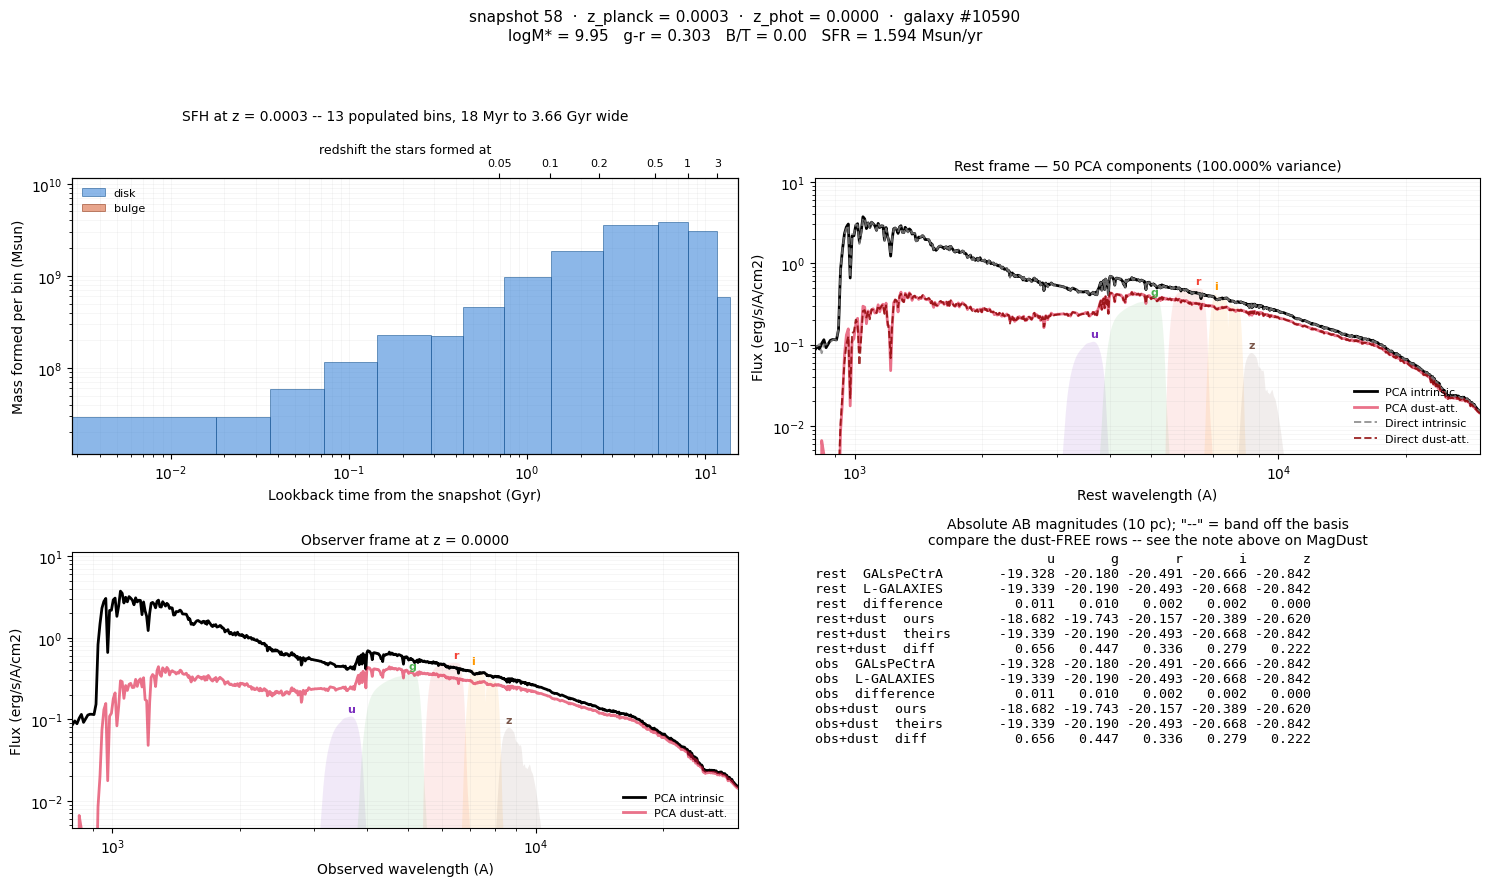

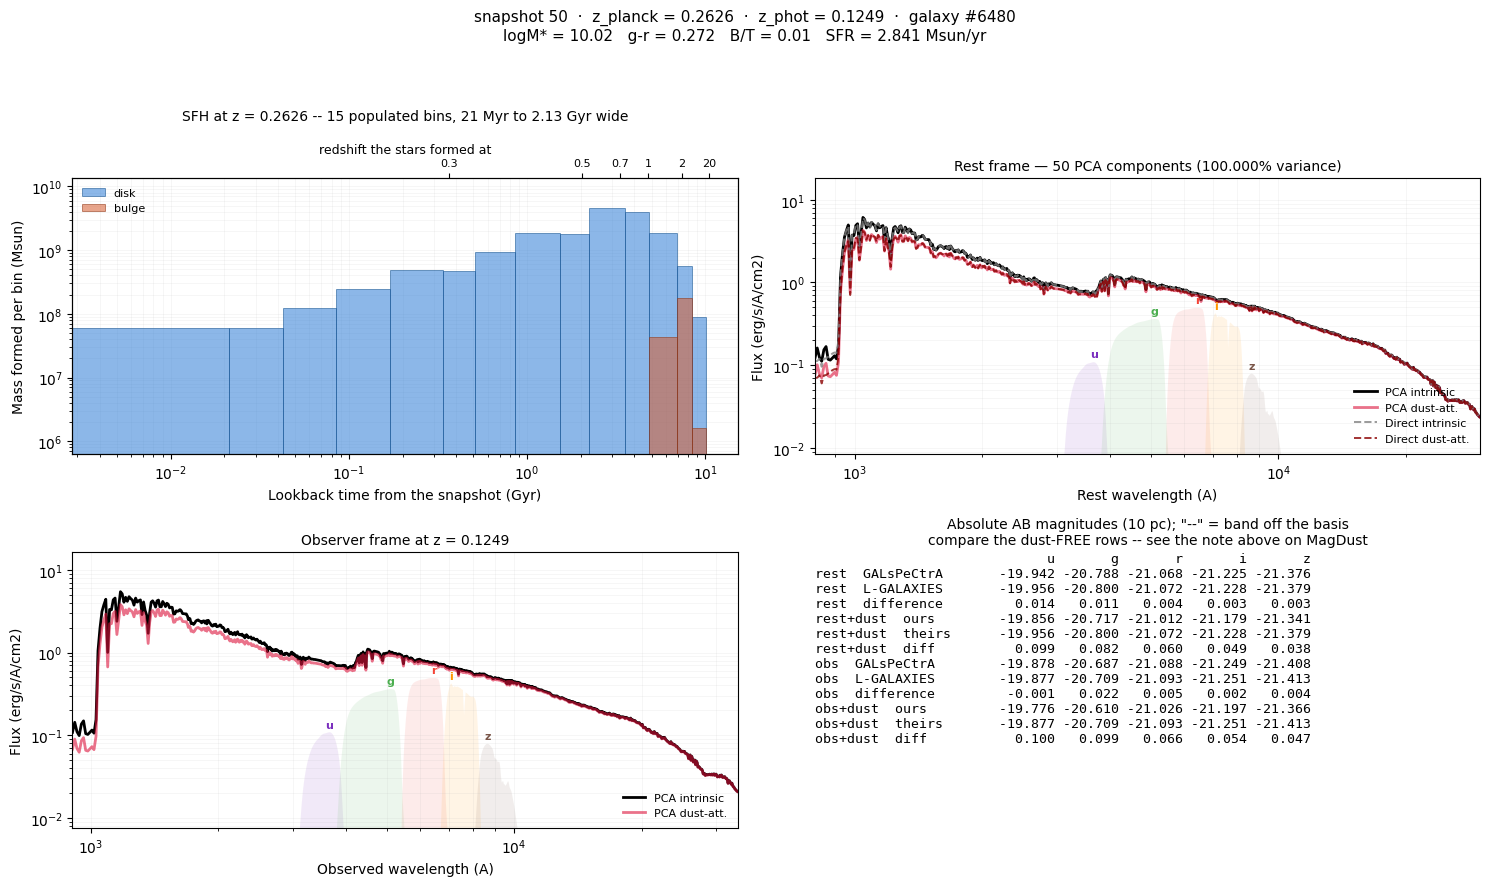

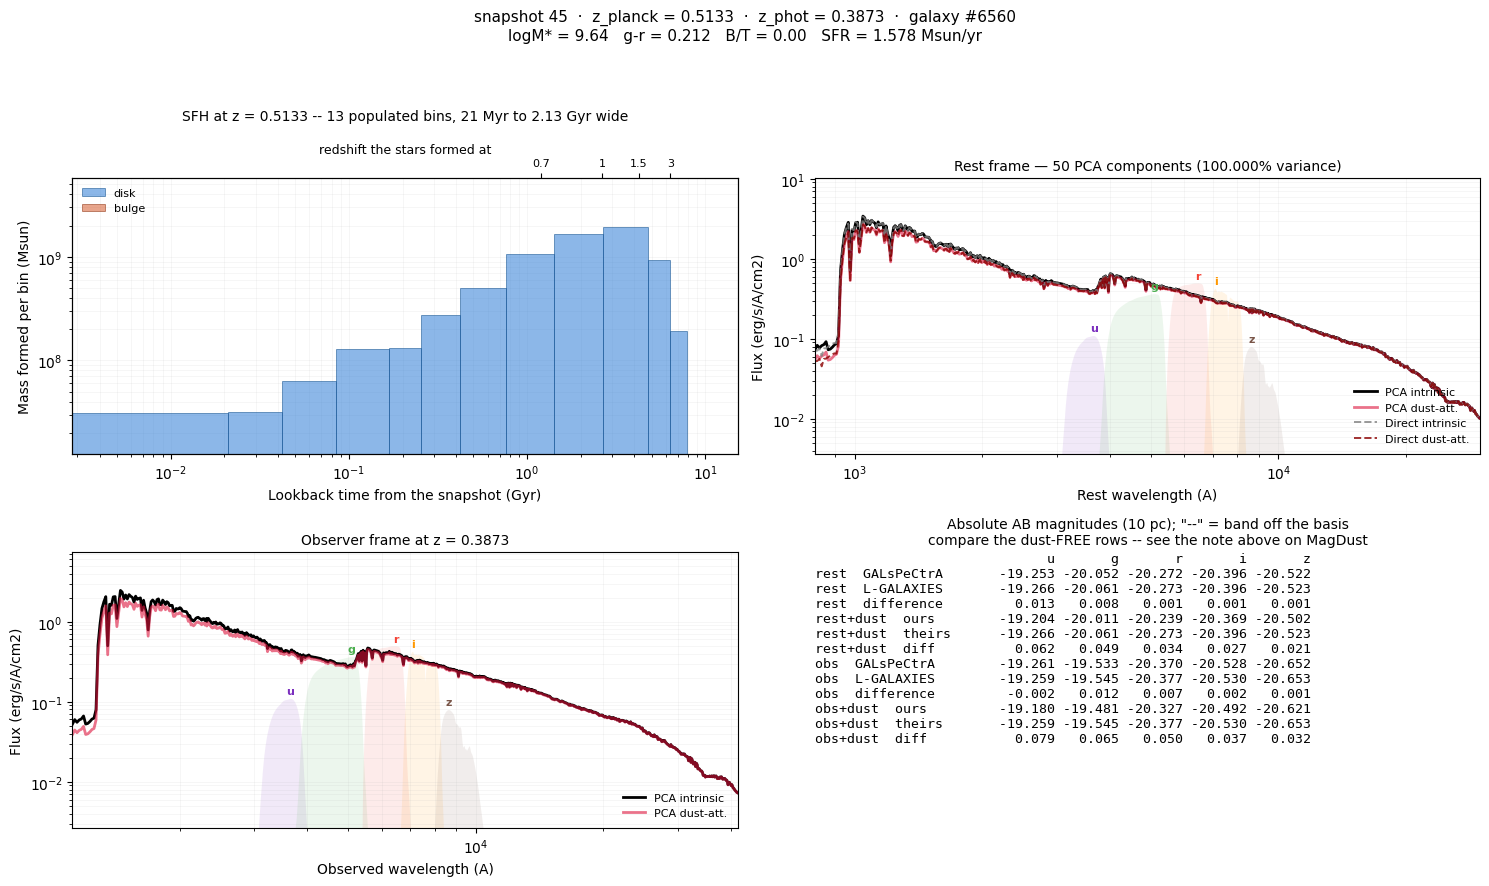

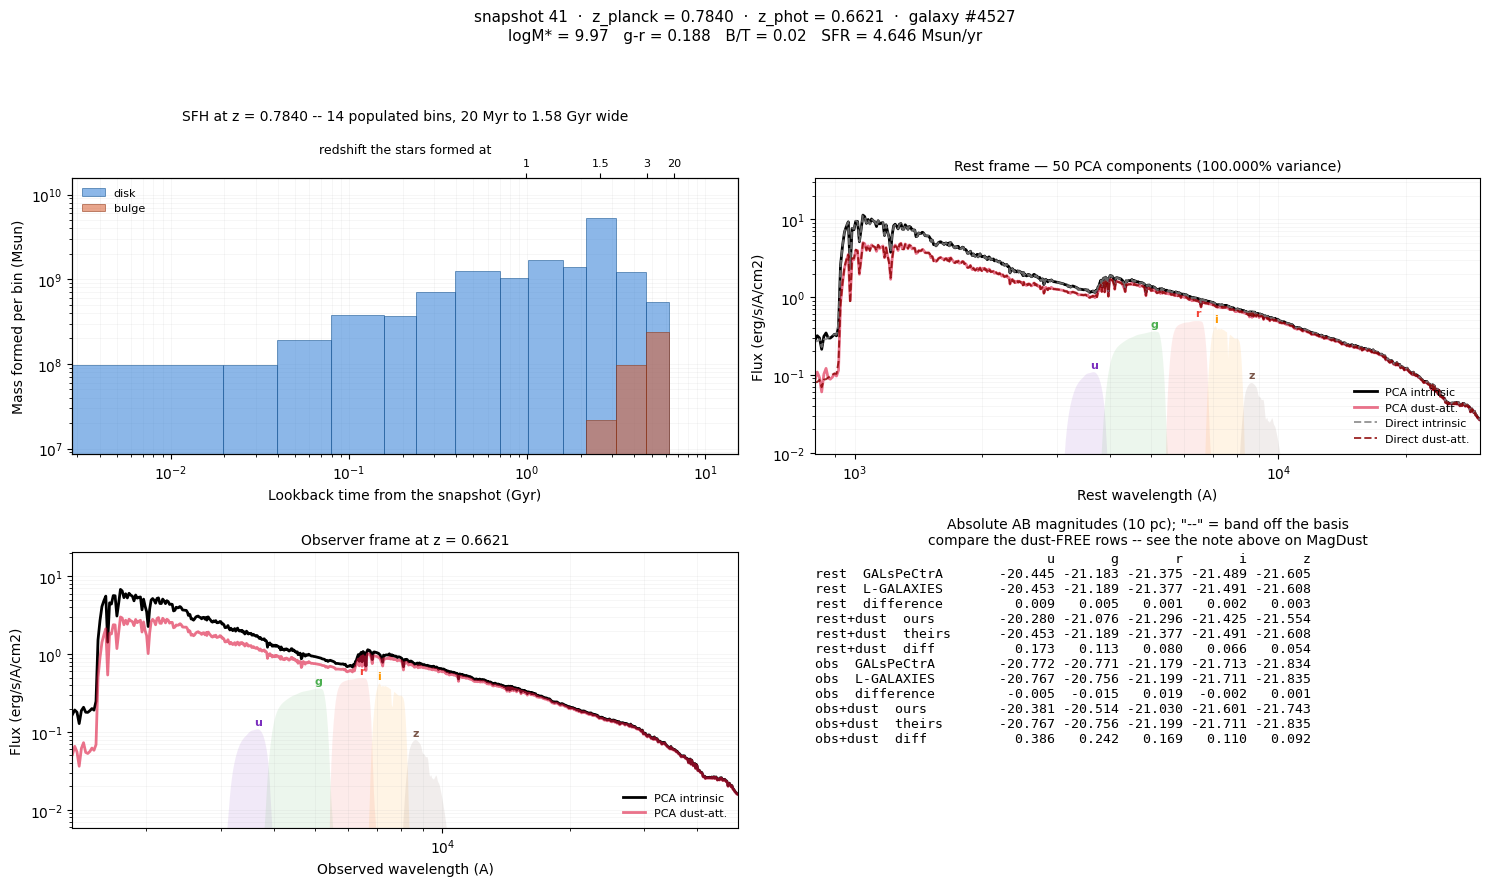

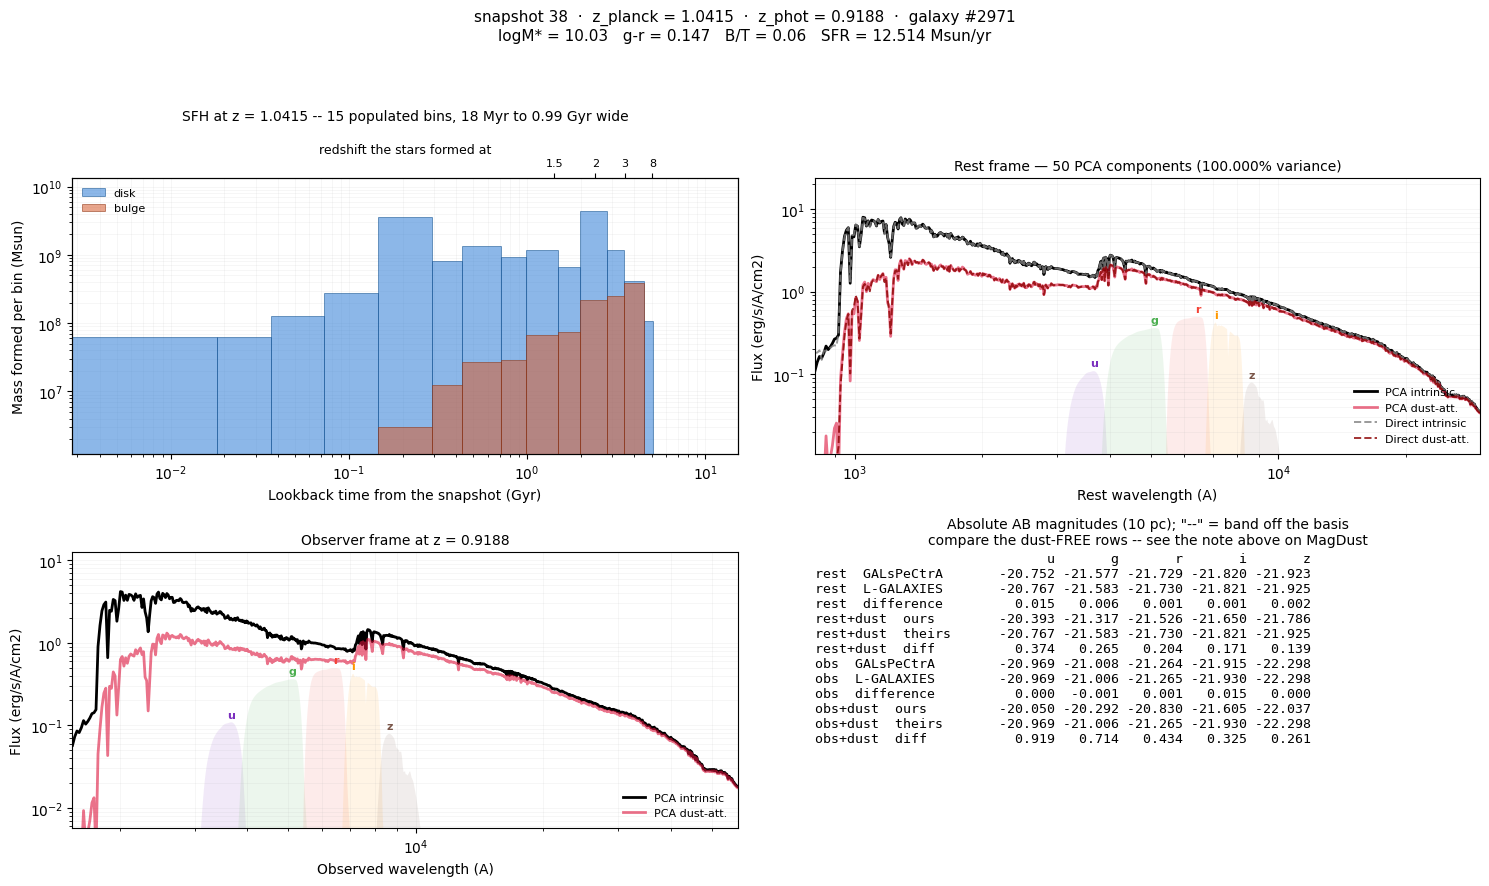

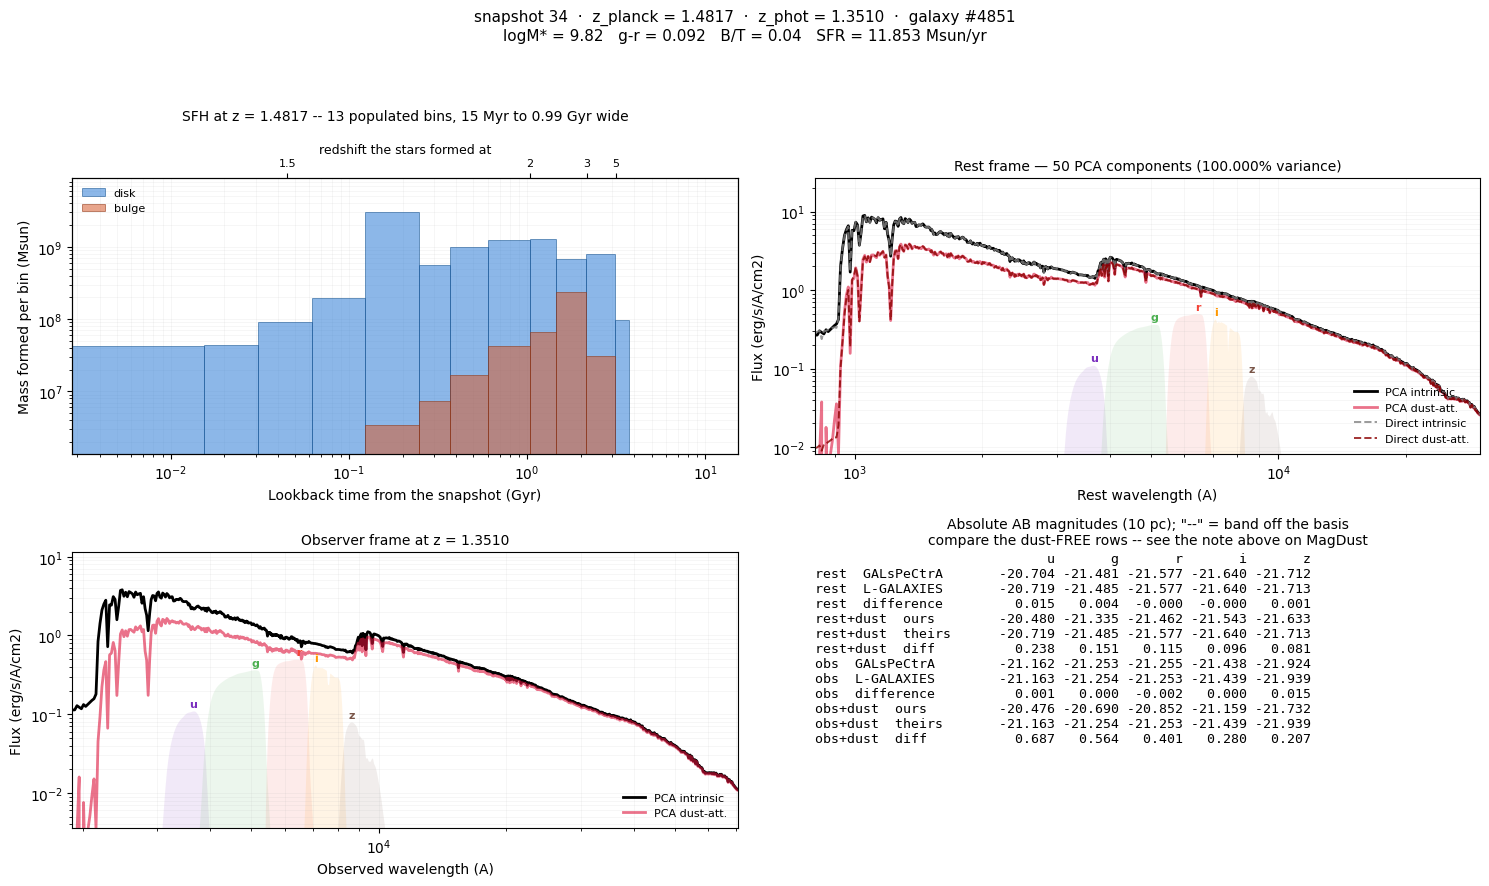

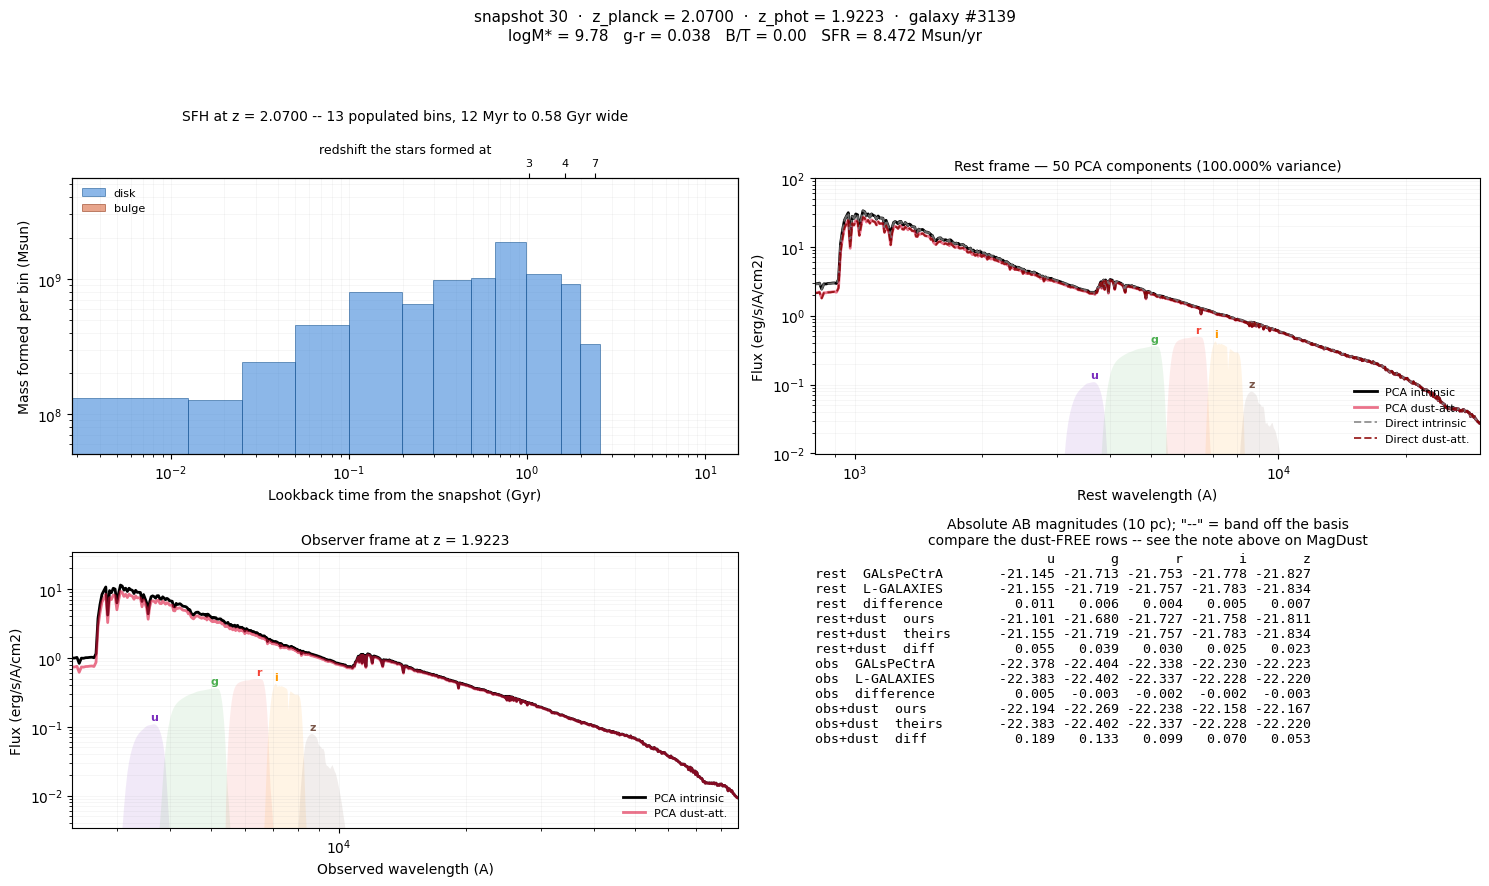

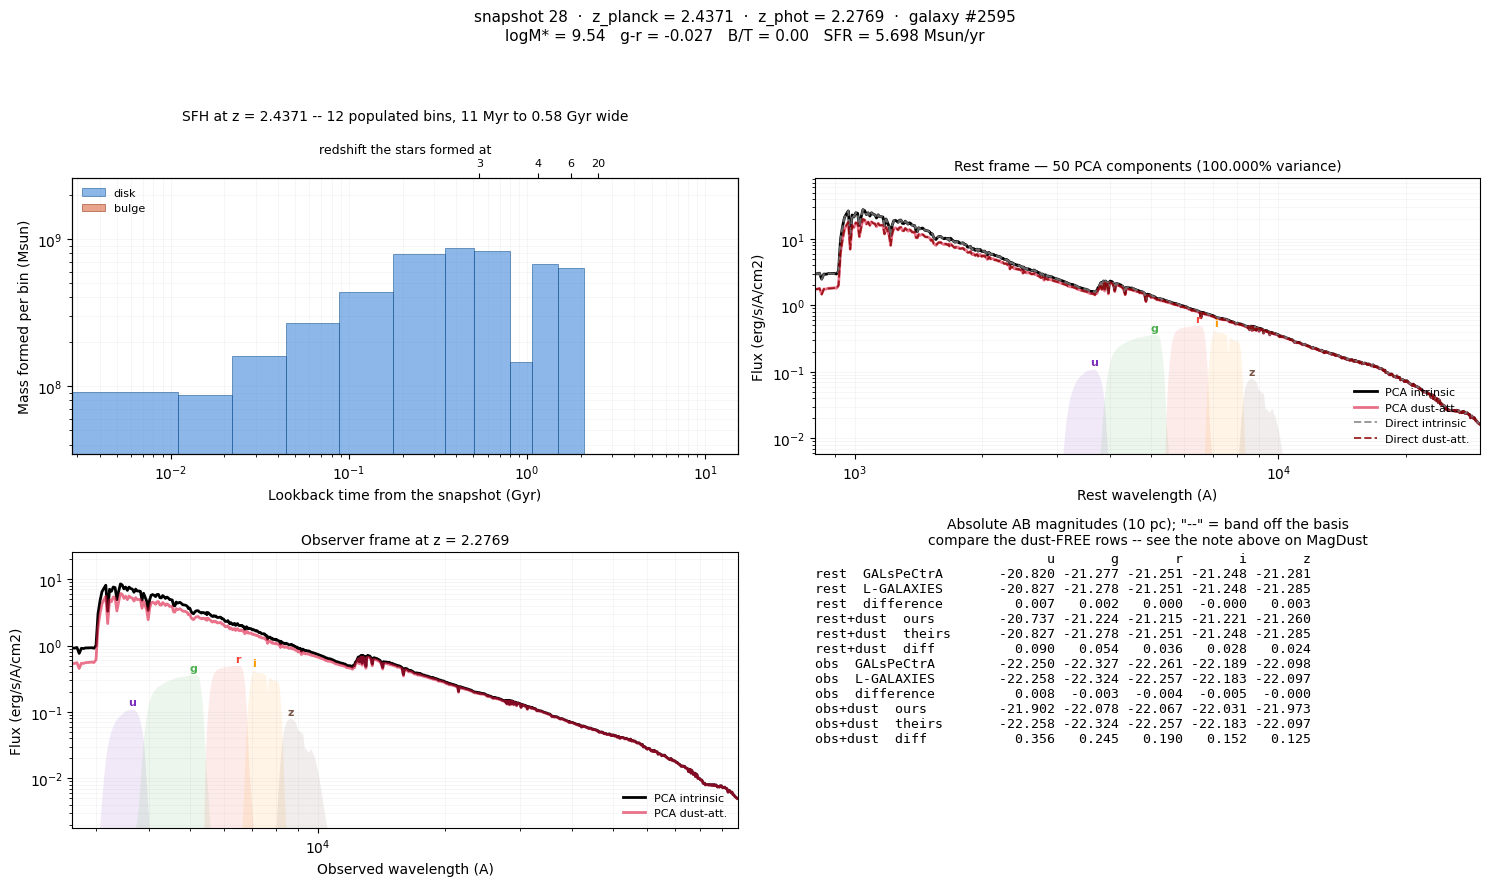

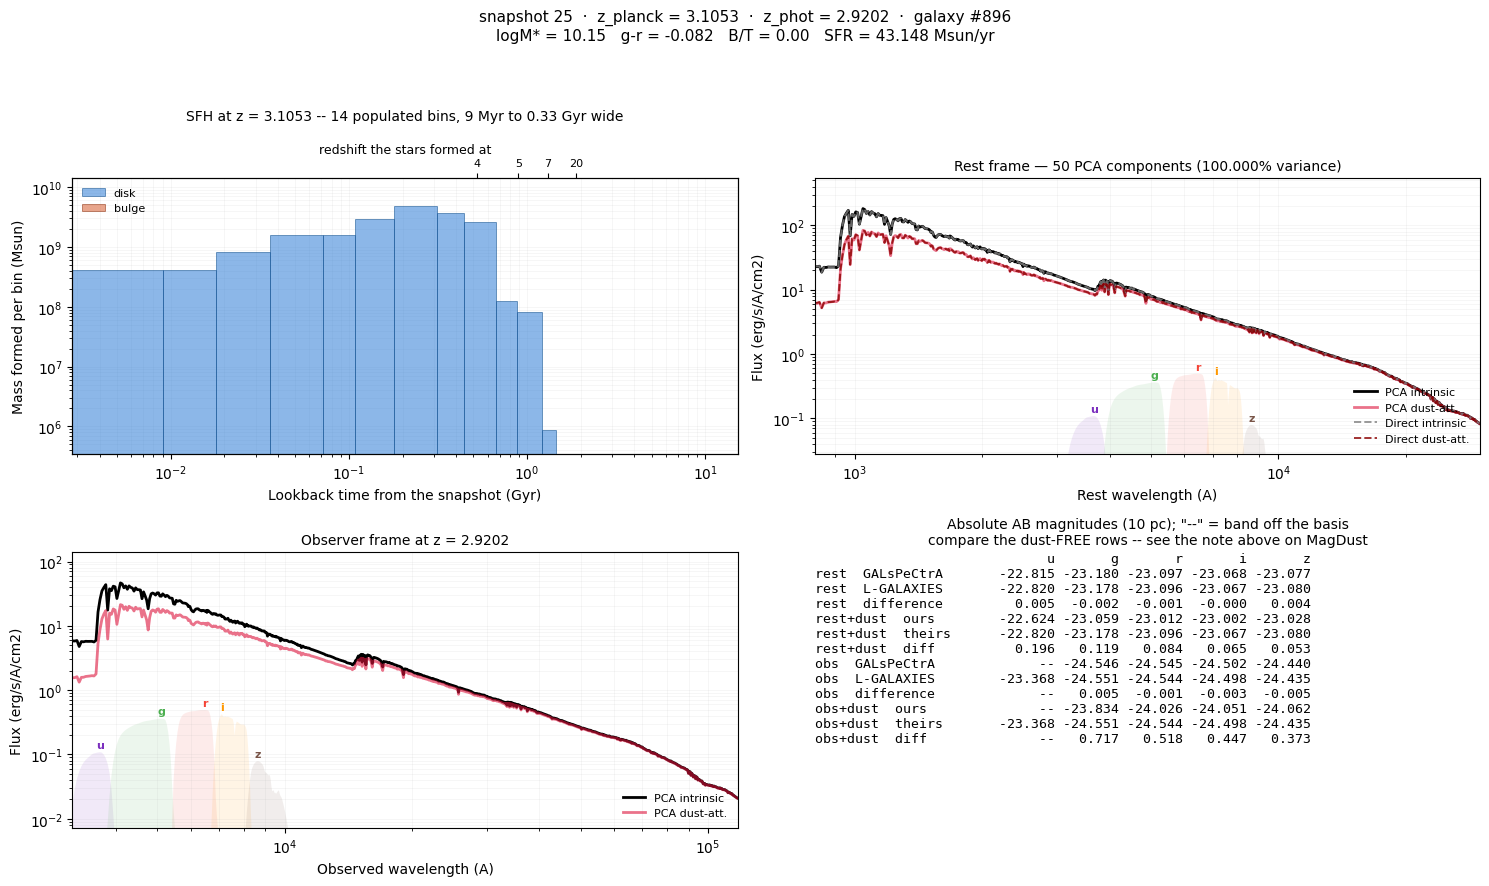

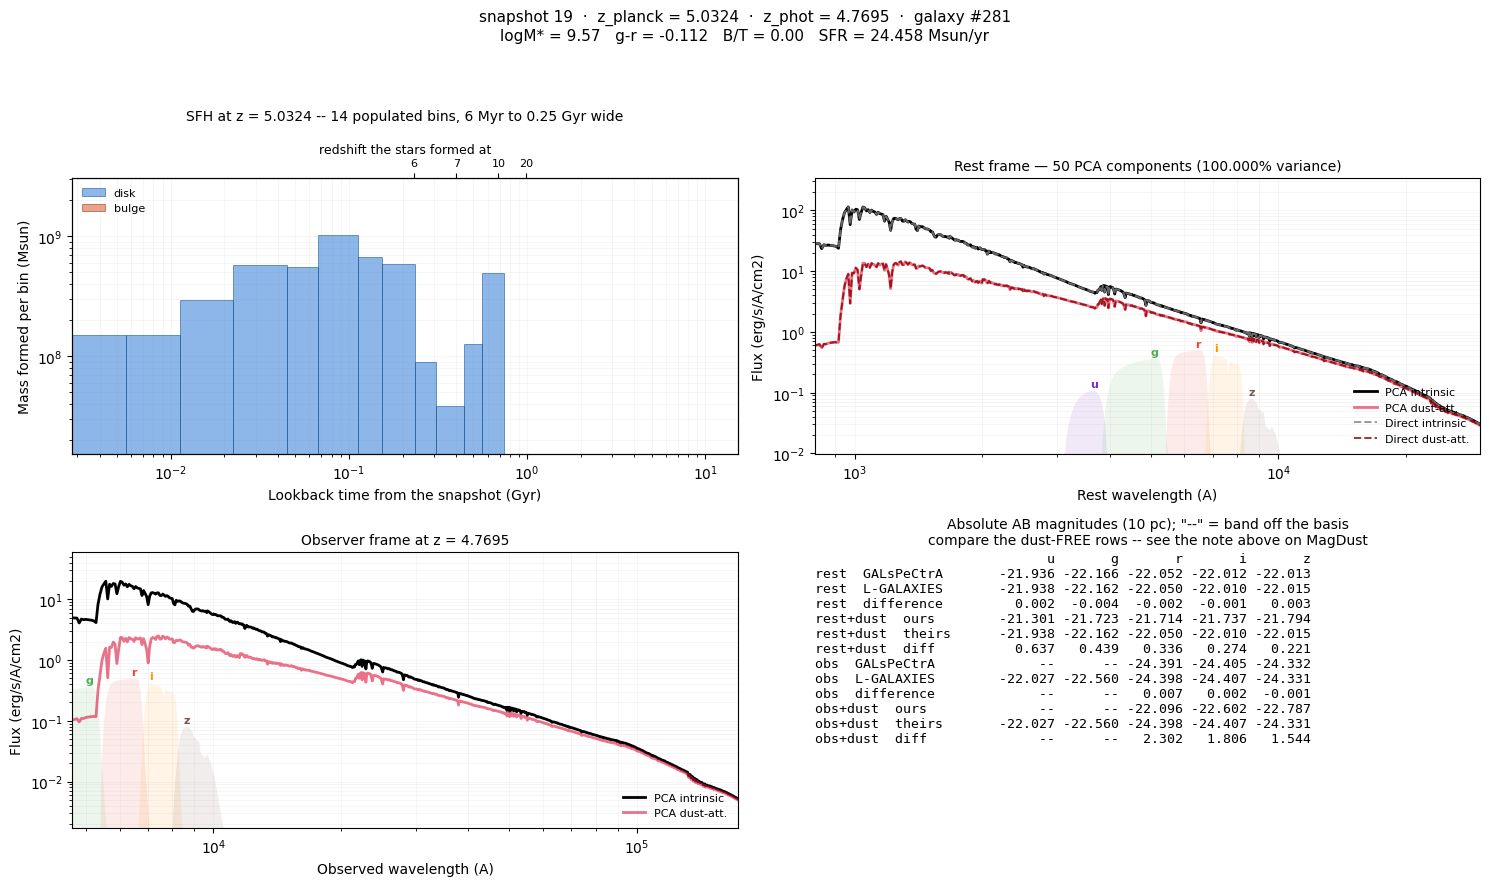

In [9]:
ARCHETYPE = 'Bluest disc'

for tag in USABLE:
    d = load_redshift(tag)
    gidx = archetypes(d).get(ARCHETYPE)
    if gidx is None:
        print(f'z{tag}: no galaxy matches "{ARCHETYPE}" — skipped')
        continue
    show(tag, gidx, n_components=50)